# Tour Auvergne-Rhône-Alpes 2026 — Stage 3

Course map and elevation profile loaded from `data/ttt_strat/input/tara2026_stage3.gpx`.

In [1]:
import math
from pathlib import Path

import gpxpy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

GPX_PATH = Path("../data/ttt_strat/input/tara2026_stage3.gpx")

In [2]:
# ── Load GPX ────────────────────────────────────────────────────────────────
with open(GPX_PATH) as fh:
    gpx = gpxpy.parse(fh)

points = [p for track in gpx.tracks for seg in track.segments for p in seg.points]

lats  = np.array([p.latitude  for p in points])
lons  = np.array([p.longitude for p in points])
elevs = np.array([p.elevation if p.elevation is not None else float("nan")
                  for p in points])

# ── Cumulative horizontal distance (haversine) ───────────────────────────────
R_m = 6_371_000.0

def _hav(lat1, lon1, lat2, lon2):
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    return 2 * R_m * math.asin(math.sqrt(a))

lats_r = np.radians(lats)
lons_r = np.radians(lons)

dist_m = np.zeros(len(points))
for i in range(1, len(points)):
    dist_m[i] = dist_m[i - 1] + _hav(lats_r[i - 1], lons_r[i - 1],
                                       lats_r[i],     lons_r[i])

dist_km = dist_m / 1_000

print(f"Points : {len(points)}")
print(f"Distance: {dist_km[-1]:.2f} km")
print(f"Elevation: {np.nanmin(elevs):.0f} – {np.nanmax(elevs):.0f} m")
print(f"Start : lat={lats[0]:.4f}°  lon={lons[0]:.4f}°  elev={elevs[0]:.0f} m")
print(f"Finish: lat={lats[-1]:.4f}°  lon={lons[-1]:.4f}°  elev={elevs[-1]:.0f} m")

Points : 873
Distance: 28.40 km
Elevation: 291 – 490 m
Start : lat=46.0455°  lon=4.1311°  elev=330 m
Finish: lat=46.0404°  lon=4.1267°  elev=347 m


Macro-segments: 218  (~130 m each)
Slope range: -10.7 % to 14.7 %


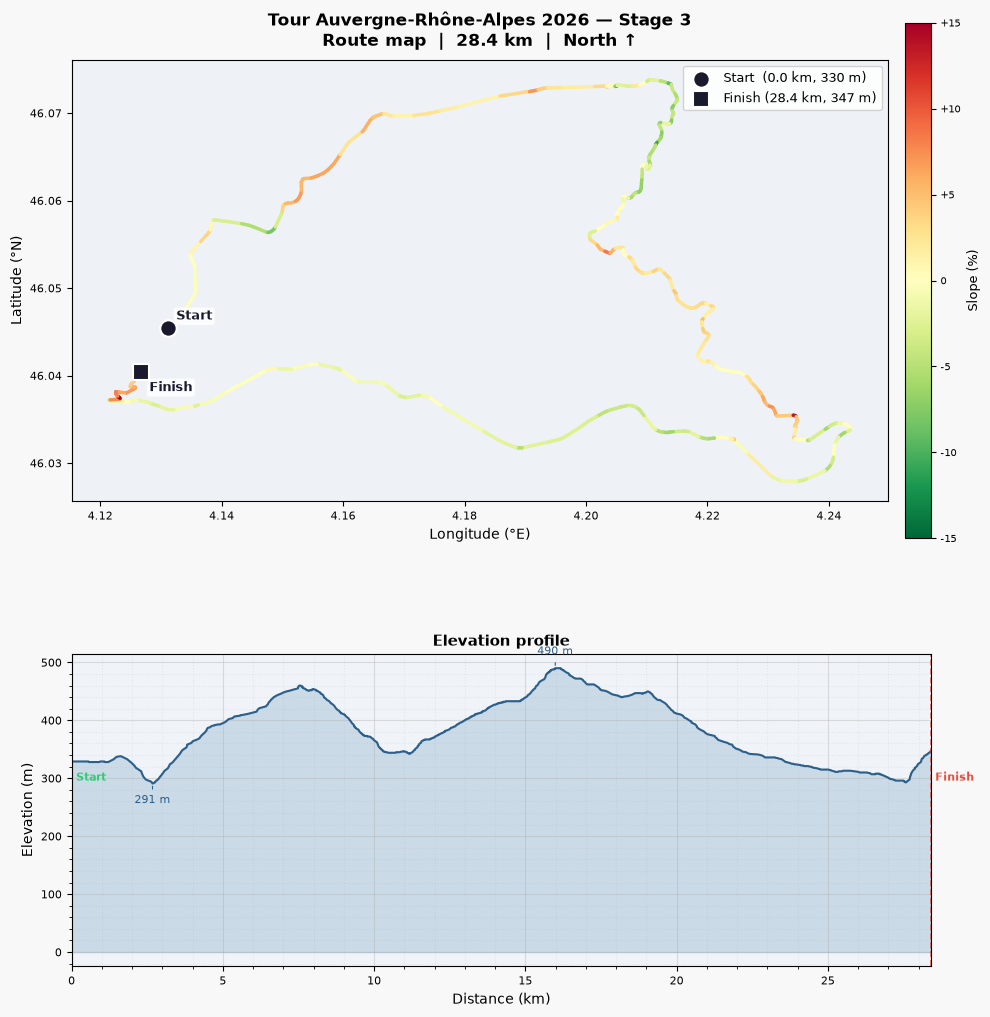

In [3]:
# ── Slope computation ────────────────────────────────────────────────────────
# GPS points are ~32 m apart; group them into larger macro-segments before
# computing slope so colour transitions are smooth and GPS noise is suppressed.
SLOPE_SEGMENT_FACTOR = 4        # each segment spans ~32 m per segment,
# slope segment = segment lenght * SLOPE_SEGMENT_FACTOR

seg_idx = np.arange(0, len(points), SLOPE_SEGMENT_FACTOR)
if seg_idx[-1] != len(points) - 1:
    seg_idx = np.append(seg_idx, len(points) - 1)

horiz_step_m = np.diff(dist_m[seg_idx])
elev_step_m  = np.diff(elevs[seg_idx])

with np.errstate(invalid="ignore", divide="ignore"):
    slopes_pct = np.where(horiz_step_m > 0,
                          elev_step_m / horiz_step_m * 100.0,
                          0.0)

# Assign each GPS segment the slope of its macro-segment
slope_per_gps = np.zeros(len(points) - 1)
for k in range(len(seg_idx) - 1):
    slope_per_gps[seg_idx[k]:seg_idx[k + 1]] = slopes_pct[k]

avg_seg_m = dist_m[-1] / len(slopes_pct)
print(f"Macro-segments: {len(slopes_pct)}  (~{avg_seg_m:.0f} m each)")
print(f"Slope range: {slopes_pct.min():.1f} % to {slopes_pct.max():.1f} %")

# ── Colour scale: span actual data range, ticks every 5 % ────────────────────
tick_min = int(np.floor(slopes_pct.min() / 5) * 5)
tick_max = int(np.ceil(slopes_pct.max() / 5) * 5)
cbar_ticks = np.arange(tick_min, tick_max + 1, 5)

cmap = plt.get_cmap("RdYlGn_r")     # red = steep up  |  yellow = flat  |  green = down
norm = plt.Normalize(vmin=tick_min, vmax=tick_max)

# ── Correct aspect ratio ─────────────────────────────────────────────────────
mean_lat_rad = np.radians(lats.mean())
aspect_corr  = 1.0 / math.cos(mean_lat_rad)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 11),
    gridspec_kw={"height_ratios": [2.2, 1]},
)
fig.patch.set_facecolor("#f8f8f8")

# ── Top: 2-D course map ───────────────────────────────────────────────────────
ax_map = axes[0]
ax_map.set_facecolor("#eef2f7")

for i in range(len(lons) - 1):
    ax_map.plot(lons[i:i+2], lats[i:i+2],
                color=cmap(norm(slope_per_gps[i])),
                linewidth=2.5, solid_capstyle="round")

ax_map.scatter(lons[0], lats[0],
               s=140, zorder=5, color="#1a1a2e", edgecolors="white", linewidths=1.5,
               label=f"Start  ({dist_km[0]:.1f} km, {elevs[0]:.0f} m)")
ax_map.annotate("Start", xy=(lons[0], lats[0]), xytext=(6, 6),
                textcoords="offset points", fontsize=9, fontweight="bold", color="#1a1a2e",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"))

ax_map.scatter(lons[-1], lats[-1],
               s=140, zorder=5, color="#1a1a2e", edgecolors="white", linewidths=1.5,
               marker="s", label=f"Finish ({dist_km[-1]:.1f} km, {elevs[-1]:.0f} m)")
ax_map.annotate("Finish", xy=(lons[-1], lats[-1]), xytext=(6, -14),
                textcoords="offset points", fontsize=9, fontweight="bold", color="#1a1a2e",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"))

ax_map.set_aspect(aspect_corr)
ax_map.set_xlabel("Longitude (°E)", fontsize=10)
ax_map.set_ylabel("Latitude (°N)", fontsize=10)
ax_map.set_title(
    "Tour Auvergne-Rhône-Alpes 2026 — Stage 3\n"
    f"Route map  |  {dist_km[-1]:.1f} km  |  North ↑",
    fontsize=12, fontweight="bold", pad=10,
)
ax_map.legend(loc="upper right", fontsize=9, framealpha=0.85)
ax_map.tick_params(labelsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_map, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Slope (%)", fontsize=9)
cbar.set_ticks(cbar_ticks)
cbar.ax.set_yticklabels([f"{t:+d}" if t != 0 else "0" for t in cbar_ticks], fontsize=7)

# ── Bottom: elevation profile ────────────────────────────────────────────────
ax_elev = axes[1]
ax_elev.set_facecolor("#f0f4f8")

ax_elev.fill_between(dist_km, elevs, alpha=0.25, color="#5b8eb5")
ax_elev.plot(dist_km, elevs, color="#2c5f8a", linewidth=1.5)

for xval, label, col in [
    (dist_km[0],  "Start",  "#2ecc71"),
    (dist_km[-1], "Finish", "#e74c3c"),
]:
    ax_elev.axvline(xval, color=col, linewidth=1.2, linestyle="--", alpha=0.8)
    ax_elev.text(xval + 0.15, np.nanmin(elevs) + 5, label,
                 color=col, fontsize=8, fontweight="bold")

ax_elev.set_xlabel("Distance (km)", fontsize=10)
ax_elev.set_ylabel("Elevation (m)", fontsize=10)
ax_elev.set_title("Elevation profile", fontsize=11, fontweight="bold")
ax_elev.set_xlim(0, dist_km[-1])
ax_elev.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax_elev.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax_elev.grid(True, which="major", linestyle="-",  alpha=0.4)
ax_elev.grid(True, which="minor", linestyle=":",  alpha=0.2)
ax_elev.tick_params(labelsize=8)

idx_max = int(np.nanargmax(elevs))
idx_min = int(np.nanargmin(elevs))
for idx, va in [(idx_max, "bottom"), (idx_min, "top")]:
    ax_elev.annotate(
        f"{elevs[idx]:.0f} m",
        xy=(dist_km[idx], elevs[idx]),
        xytext=(0, 8 if va == "bottom" else -8), textcoords="offset points",
        ha="center", va=va, fontsize=8, color="#2c5f8a",
        arrowprops=dict(arrowstyle="-", color="#2c5f8a", lw=0.8),
    )

plt.tight_layout(h_pad=2.5)
plt.savefig("../docs/stage3_course.png", dpi=150, bbox_inches="tight")
plt.show()

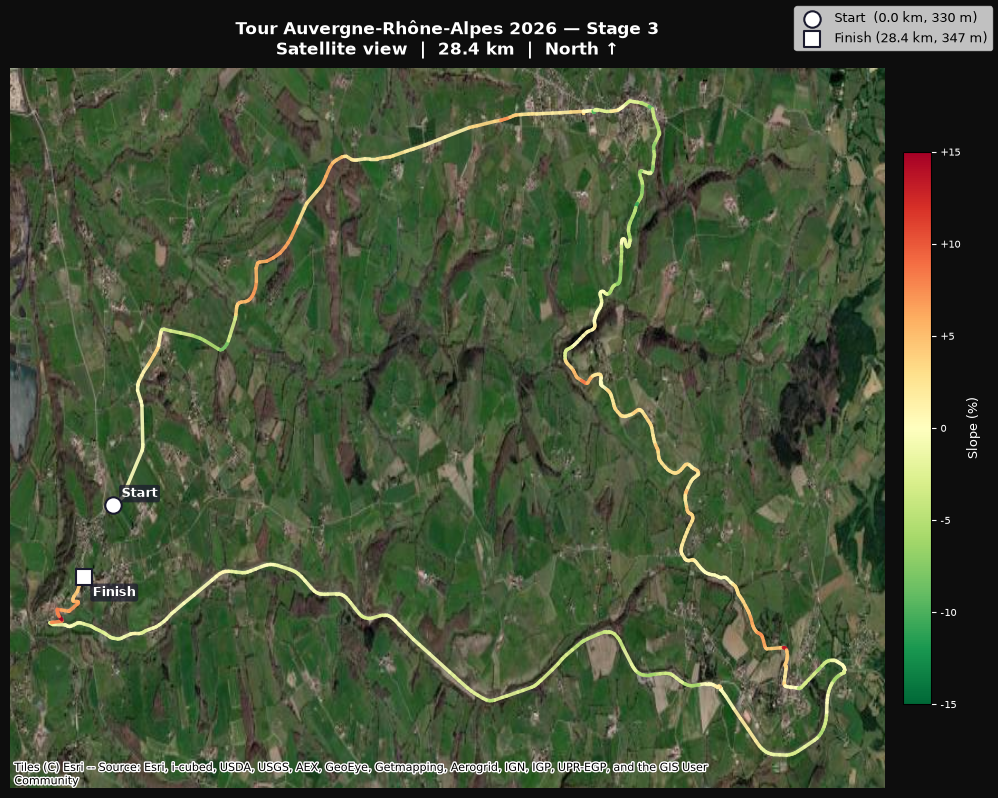

Saved → docs/stage3_course_satellite.png


In [4]:
import contextily as ctx

# ── Convert WGS-84 → Web Mercator (EPSG:3857) ────────────────────────────────
# Standard Web Mercator projection formula (same as EPSG:3857)
_R_web = 6_378_137.0
xs = np.radians(lons) * _R_web
ys = np.log(np.tan(np.pi / 4 + np.radians(lats) / 2)) * _R_web

# ── Figure ───────────────────────────────────────────────────────────────────
fig_sat, ax_sat = plt.subplots(figsize=(10, 8))
fig_sat.patch.set_facecolor("#0d0d0d")

# Route segments coloured by slope (reuses slope_per_gps, cmap, norm from previous cell)
for i in range(len(xs) - 1):
    ax_sat.plot(xs[i:i+2], ys[i:i+2],
                color=cmap(norm(slope_per_gps[i])),
                linewidth=2.5, solid_capstyle="round", alpha=0.9)

# Start marker
ax_sat.scatter(xs[0], ys[0], s=140, zorder=5,
               color="#ffffff", edgecolors="#1a1a2e", linewidths=1.5,
               label=f"Start  ({dist_km[0]:.1f} km, {elevs[0]:.0f} m)")
ax_sat.annotate("Start", xy=(xs[0], ys[0]), xytext=(6, 6),
                textcoords="offset points", fontsize=9, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc="#1a1a2e", alpha=0.7, ec="none"))

# Finish marker
ax_sat.scatter(xs[-1], ys[-1], s=140, zorder=5, marker="s",
               color="#ffffff", edgecolors="#1a1a2e", linewidths=1.5,
               label=f"Finish ({dist_km[-1]:.1f} km, {elevs[-1]:.0f} m)")
ax_sat.annotate("Finish", xy=(xs[-1], ys[-1]), xytext=(6, -14),
                textcoords="offset points", fontsize=9, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc="#1a1a2e", alpha=0.7, ec="none"))

# Satellite basemap (Esri WorldImagery — requires internet access; tiles cached locally)
ctx.add_basemap(ax_sat, source=ctx.providers.Esri.WorldImagery, zoom="auto",
                crs="EPSG:3857")

ax_sat.set_axis_off()
ax_sat.set_title(
    "Tour Auvergne-Rhône-Alpes 2026 — Stage 3\n"
    f"Satellite view  |  {dist_km[-1]:.1f} km  |  North ↑",
    fontsize=12, fontweight="bold", color="white", pad=10,
)
fig_sat.legend(loc="upper right", fontsize=9, framealpha=0.75)

sm_sat = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm_sat.set_array([])
cbar_sat = fig_sat.colorbar(sm_sat, ax=ax_sat, orientation="vertical",
                             fraction=0.03, pad=0.02)
cbar_sat.set_label("Slope (%)", fontsize=9, color="white")
cbar_sat.set_ticks(cbar_ticks)
cbar_sat.ax.set_yticklabels([f"{t:+d}" if t != 0 else "0" for t in cbar_ticks], fontsize=7)
cbar_sat.ax.yaxis.set_tick_params(color="white", labelcolor="white")

plt.tight_layout()
plt.savefig("../docs/stage3_course_satellite.png", dpi=150, bbox_inches="tight",
            facecolor="#0d0d0d")
plt.show()
print("Saved → docs/stage3_course_satellite.png")

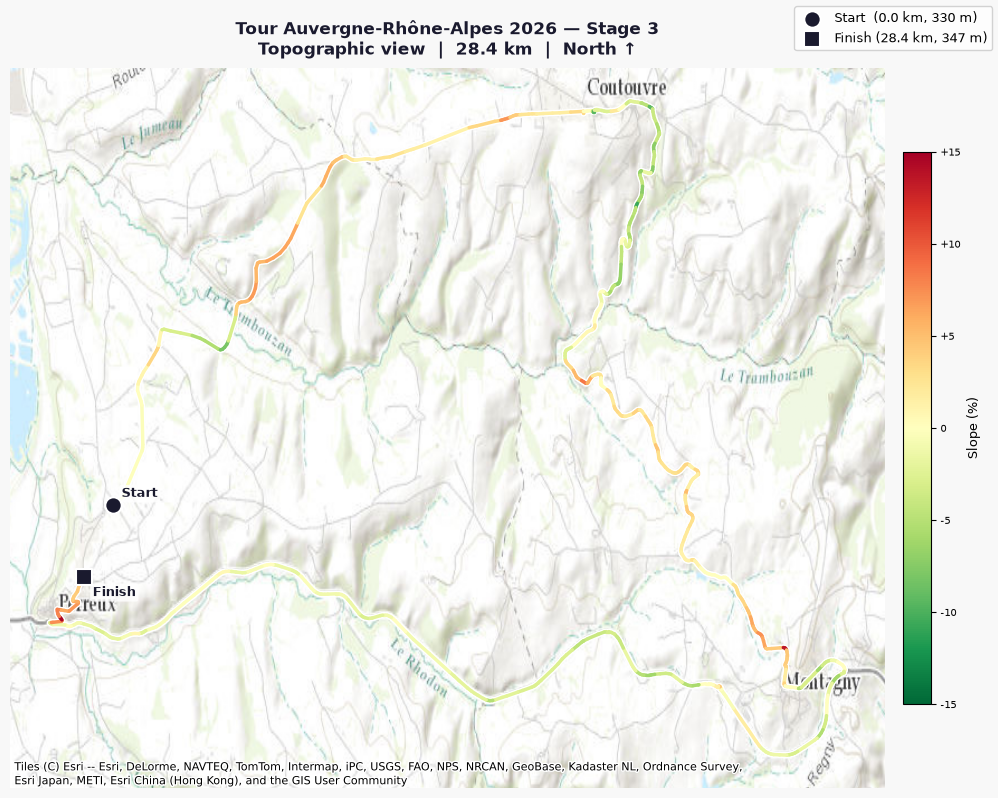

Saved → docs/stage3_course_topo.png


In [5]:
# ── Topographic basemap overlay ───────────────────────────────────────────────
# xs, ys (Web Mercator) already computed in previous cell

fig_topo, ax_topo = plt.subplots(figsize=(10, 8))
fig_topo.patch.set_facecolor("#f8f8f8")

# White halo first so slope colours are readable against the map background
for i in range(len(xs) - 1):
    ax_topo.plot(xs[i:i+2], ys[i:i+2], color="white", linewidth=4.5,
                 solid_capstyle="round", zorder=2)

# Slope-coloured route on top
for i in range(len(xs) - 1):
    ax_topo.plot(xs[i:i+2], ys[i:i+2],
                 color=cmap(norm(slope_per_gps[i])),
                 linewidth=2.5, solid_capstyle="round", zorder=3)

# Start marker
ax_topo.scatter(xs[0], ys[0], s=140, zorder=5,
                color="#1a1a2e", edgecolors="white", linewidths=1.5,
                label=f"Start  ({dist_km[0]:.1f} km, {elevs[0]:.0f} m)")
ax_topo.annotate("Start", xy=(xs[0], ys[0]), xytext=(6, 6),
                 textcoords="offset points", fontsize=9, fontweight="bold", color="#1a1a2e",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"))

# Finish marker
ax_topo.scatter(xs[-1], ys[-1], s=140, zorder=5, marker="s",
                color="#1a1a2e", edgecolors="white", linewidths=1.5,
                label=f"Finish ({dist_km[-1]:.1f} km, {elevs[-1]:.0f} m)")
ax_topo.annotate("Finish", xy=(xs[-1], ys[-1]), xytext=(6, -14),
                 textcoords="offset points", fontsize=9, fontweight="bold", color="#1a1a2e",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"))

# Esri WorldTopoMap — clean professional topo with full global coverage (no API key needed)
ctx.add_basemap(ax_topo, source=ctx.providers.Esri.WorldTopoMap, zoom="auto", crs="EPSG:3857")

ax_topo.set_axis_off()
ax_topo.set_title(
    "Tour Auvergne-Rhône-Alpes 2026 — Stage 3\n"
    f"Topographic view  |  {dist_km[-1]:.1f} km  |  North ↑",
    fontsize=12, fontweight="bold", color="#1a1a2e", pad=10,
)
fig_topo.legend(loc="upper right", fontsize=9, framealpha=0.85)

sm_topo = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm_topo.set_array([])
cbar_topo = fig_topo.colorbar(sm_topo, ax=ax_topo, orientation="vertical",
                               fraction=0.03, pad=0.02)
cbar_topo.set_label("Slope (%)", fontsize=9)
cbar_topo.set_ticks(cbar_ticks)
cbar_topo.ax.set_yticklabels([f"{t:+d}" if t != 0 else "0" for t in cbar_ticks], fontsize=7)

plt.tight_layout()
plt.savefig("../docs/stage3_course_topo.png", dpi=150, bbox_inches="tight",
            facecolor="#f8f8f8")
plt.show()
print("Saved → docs/stage3_course_topo.png")